In [5]:
import s3fs
import os
import pandas as pd
import time
import numpy as np
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import pandas as pd
from tqdm import tqdm
import os
from tqdm import tqdm
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import io
import json


# S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"] #  on récupère l'url du stockage s3

# # on peut désormais instancier le filesystem en précisant l'url du stockage S3

# fs = s3fs.S3FileSystem(endpoint_url= S3_ENDPOINT_URL)


import psutil


# Get total memory in bytes
total_memory = psutil.virtual_memory().total

# Convert bytes to GB (optional, for readability)
total_memory_in_gb = total_memory / (1024 ** 3)

print(f"Total RAM: {total_memory_in_gb:.2f} GB")


Total RAM: 31.43 GB


In [275]:
df = pd.read_parquet("data/JOCAS/small/jocas_small_all_half_sirenised_embed_job_title.parquet")

In [312]:
df

,ID_JOCAS,annee,mois,entreprise_nom,location_zipcode,description,job_ROME_code,contractType,SIREN,NAF_Code,Employee_Range,Company_Category,Director_Birth_Year,Company_Creation_Date,description_clean,embedding,embedding_pca,job_title
0,api_poleemploi_2023-04-28_78538,2023,4,None,31000,vous serez responsable du food truck pendant l...,G1401,CDI,,,,,,,vous serez responsable du food truck pendant l...,"[-0.037508223, 0.0065497477, -0.0007974197, -0...","[-0.037707433, 0.068371095, -0.09466716, -0.07...",Assistant / Assistante manager en restauration...
1,jobintree_2023-05-19_48068,2023,5,aunis sud,None,description du poste :avec des clients dans pl...,M1707,CDI,200041614,84.11Z,None,PME,0.0,2014-01-01,description du poste :avec des clients dans pl...,"[-0.06067792, 0.024671966, -0.024764137, -0.06...","[-0.021875896, 0.014739902, 0.020539891, -0.12...",business developer (h/f)
2,hellowork_bureau_etude_r_d_2023-03-17_1065,2023,3,None,None,vous êtes issu d'une formation supérieure typ...,,None,,,,,,,vous êtes issu d'une formation supérieure type...,"[-0.10698657, -0.06519823, -0.10766974, -0.079...","[-0.14357577, -0.23011383, 0.04959557, -0.0691...",
3,jobintree_2023-06-07_33116,2023,6,win sport school,56000,"description du poste :win sport school vannes,...",M1705,Alternance,904549961,93.12Z,None,None,0.0,2021-10-13,description du poste :win sport school vannes ...,"[-0.010242393, 0.011192331, -0.062002324, -0.1...","[0.0026179682, -0.122466154, 0.050591026, -0.2...",chargé de marketing digital en alternance (h/f)
4,hellowork_logistique_metiers_transport_2023-03...,2023,3,assystem,1150.0,qualifications vous recherchez une alternance...,N1301,CDI,412076937,70.10Z,None,ETI,1968,1997-04-26,qualifications vous recherchez une alternance ...,"[-0.09042679, -0.088197626, -0.04862888, -0.04...","[-0.10935141, -0.059904385, -0.0069309566, -0....",Chargé d'Affaires Logistique - Alternance H/F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804992,JOBINTREE_2020-12-05_8970,2020,12,lustral,39100.0,"nous recherchons une gouvernant d'intérieur, m...",K1304,CDI,,,,,,,"nous recherchons une gouvernant d'intérieur, m...","[-0.063871354, -0.0012015791, -0.036611278, -0...","[-0.114256166, -0.05006772, 0.10313746, 0.1643...",Emploi gouvernant / gouvernante à domicile (h/f)
804993,JOBINTREE_2020-01-24_77816,2020,1,la pie verte,31700.0,préparation de commandes et livraisons de repa...,N4105,CDD,,,,,,,préparation de commandes et livraisons de repa...,"[-0.07240109, 0.0437684, -0.037568178, -0.0340...","[-0.07467285, -0.12754369, 0.06715377, 0.07164...",Emploi chauffeur-livreur préparateur / chauffe...
804994,JOBINTREE_2020-02-20_19748,2020,2,jvs mairistem,51520.0,tes missions : au sein de notre service commer...,D1401,CDI,,,,,,,tes missions : au sein de notre service commer...,"[-0.099452265, -0.014010274, -0.037381187, -0....","[-0.08108935, -0.23834908, 0.14693095, -0.1298...",Emploi commercial / commerciale sédentaire (h/f)
804995,API_POLEEMPLOI_2020-10-28_4237,2020,10,None,49700.0,description du poste :\nvous mettez en œuvre d...,F1703,MIS,,,,,,,description du poste : vous mettez en œuvre de...,"[-0.065282054, 0.10251117, -0.017559458, -0.05...","[0.04462664, 0.1744917, -0.2265024, -0.1451148...",Maçon / Maçonne (H/F)


In [276]:
import numpy as np

def cosine_similarity_matrix(X: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between all rows of X.
    X: (n, d)
    Returns: (n, n)
    """
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    return X_norm @ X_norm.T

# Grouping by SIREN/ROME/SIRENxROME

In [277]:
# 3) Firm centroid in PCA space (mean over offers)

firm_centroids = (
    df.groupby("SIREN")["embedding_pca"]
      .apply(lambda s: np.mean(np.vstack(s.to_numpy()), axis=0))
      .reset_index(name="centroid")
)

# Optional: number of offers per firm
firm_centroids["n_offers"] = df.groupby("SIREN").size().values

In [278]:
firm_centroids

,SIREN,centroid,n_offers
0,,"[-0.003755128, 0.01081372, -0.00027459065, 0.0...",543878
1,005781133,"[0.016974803, -0.133729, -0.015744353, -0.0002...",14
2,015851793,"[-0.07103579, 0.15079534, -0.10085728, -0.1008...",14
3,015980048,"[0.020075645, 0.04438716, -0.05135136, -0.0900...",32
4,016850042,"[-0.12934668, 0.056673422, 0.084233046, 0.1160...",26
...,...,...,...
6239,987418670,"[-0.031333584, -0.19747125, 0.045586523, 0.020...",3
6240,987593415,"[-0.14372611, -0.3439732, -0.17560057, 0.09222...",1
6241,987603446,"[-0.090294614, 0.008362839, 0.0076391147, -0.0...",86
6242,998823504,"[0.32825378, -0.12411638, -0.029245006, 0.0375...",85


In [279]:
rome_centroids = (
    df.groupby("job_ROME_code")["embedding_pca"]
      .apply(lambda s: np.mean(np.vstack(s.to_numpy()), axis=0))
      .reset_index(name="centroid")
)

rome_centroids["n_offers"] = df.groupby("job_ROME_code").size().values

# regex: start ^, one capital letter [A-Z], 4 digits \d{4}, end $
mask_valid = rome_centroids["job_ROME_code"].str.match(r"^[A-Z]\d{4}$", na=False)

rome_centroids = rome_centroids.loc[mask_valid].reset_index(drop=True)

In [280]:
df[df['job_ROME_code']=='A1101'].iloc[0]['description_clean']

"au sein du groupe interaction, nous proposons des solutions de recrutement (intérim, cdd, cdi, formation) pour accompagner le développement de l'activité des pme, eti et grandes entreprises, dans le respect de nos engagements rse. en faisant vivre nos valeurs (liberté, engagement, exigence, collectif, sur-mesure et proximité), nous plaçons l'humain au coeur de notre activité. notre groupe, né en bretagne en 1991, développe son expertise et ses compétences par l'action des 800 co-acteurs répartis dans plus de 170 agences et cabinets sur tout le territoire national français. notre métier : capter, gérer et faire grandir les talents. pour chaque besoin, une solution existe au sein du groupe interaction. que ce soit en intérim, en cdd, en cdi ou en formation, nous recrutons les candidats qui accompagneront la croissance des entreprises. et parce que chaque besoin est unique, nous avons développé une offre large de solutions personnalisées et de prestations digitales. interaction crée pour

In [281]:
rome_centroids

,job_ROME_code,centroid,n_offers
0,A1101,"[-0.037139878, 0.062274467, -0.12041541, 0.012...",396
1,A1201,"[-0.058157314, 0.04054348, -0.09153709, 0.0266...",363
2,A1202,"[-0.04751773, 0.034951486, -0.04229214, 0.0453...",131
3,A1203,"[-0.058718372, 0.06941522, -0.04361077, -0.017...",3342
4,A1204,"[0.07373878, 0.007233471, -0.04757048, 0.12402...",22
...,...,...,...
526,N4301,"[-0.023384592, 0.001740705, -0.09922697, 0.002...",135
527,N4302,"[-0.08420133, -0.03995138, -0.0026393835, -0.0...",36
528,N4401,"[-0.071125254, -0.045126077, -0.084756196, 0.0...",125
529,N4402,"[-0.04330245, -0.047705334, -0.051071472, 0.04...",43


In [282]:
firm_centroids.to_parquet("data/JOCAS/firm_centroids.parquet")
rome_centroids.to_parquet("data/JOCAS/rome_centroids.parquet")

In [283]:
df[df['job_ROME_code']=='A1101']

,ID_JOCAS,annee,mois,entreprise_nom,location_zipcode,description,job_ROME_code,contractType,SIREN,NAF_Code,Employee_Range,Company_Category,Director_Birth_Year,Company_Creation_Date,description_clean,embedding,embedding_pca,job_title
2977,api_poleemploi_2023-06-29_88323,2023,6,interaction martigues,13230,"au sein du groupe interaction, nous proposons ...",A1101,MIS,,,,,,,"au sein du groupe interaction, nous proposons ...","[-0.07482019, -0.028180232, -0.0422388, -0.079...","[-0.14477107, -0.018339803, 0.07947345, -0.122...",Conducteur / Conductrice de pulvérisateur (H/F)
3378,api_poleemploi_2023-02-13_63485,2023,2,sarl endives de neuville,62124,vous réaliserez des travaux agricoles (prépara...,A1101,CDD,,,,,,,vous réaliserez des travaux agricoles (prépara...,"[-0.059637967, -0.026105292, -0.03871929, -0.0...","[-0.008205173, 0.035614513, -0.2846952, 0.0215...",Conducteur / Conductrice de tracteur
6674,leboncoin_2023-03-29_753,2023,3,temporis falaise,14700,résuméconducteur / conductrice de tracteur (h/...,A1101,MIS,853713394,78.20Z,None,PME,0.0,2019-09-05,résuméconducteur / conductrice de tracteur (h/...,"[-0.060152873, 0.032867804, -0.002235464, -0.0...","[-0.11265945, 0.09392135, -0.10136641, 0.03294...",Conducteur / Conductrice de tracteur (H/F)
12868,jobintree_2023-12-29_38117,2023,12,earl verdure antoine,80132,description du poste :vous serez amené à labou...,A1101,CDI,,,,,,,description du poste :vous serez amené à labou...,"[-0.035811357, 0.059950367, -0.05352168, -0.05...","[-0.05400907, 0.019090367, -0.20654713, 0.1446...",conducteur / conductrice de tracteur (h/f)
16095,api_poleemploi_2023-10-20_36207,2023,10,elioreso,44320,"rejoignez une entreprise productrice de mâche,...",A1101,CDD,,,,,,,"rejoignez une entreprise productrice de mâche,...","[0.008638408, -0.006257395, -0.025100652, -0.0...","[-0.10823818, 0.10634629, -0.12643558, 0.04022...",Agent tractoriste en maraîchage (H/F)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799524,JOBINTREE_2020-03-13_12642,2020,3,mairie muret,31600.0,"missions : - conduire les engins agricoles, tr...",A1101,CDD,,,,,,,"missions : - conduire les engins agricoles, tr...","[0.0058694803, -0.015769798, -0.06676956, -0.0...","[-0.16184056, -0.068179764, 0.00021688656, 0.1...",Emploi conducteur d'engins agricoles (h/f)
799753,API_POLEEMPLOI_2020-04-30_5762,2020,4,luc serin-moulin,45150.0,pour un contrat à partir du 20 juin prochain s...,A1101,CDD,,,,,,,pour un contrat à partir du 20 juin prochain s...,"[-0.059490953, 0.04705801, -0.03648002, -0.082...","[-0.015818525, 0.07157196, -0.2613563, -0.1077...",Conducteur / Conductrice d'engins d'exploitati...
800419,API_POLEEMPLOI_2020-10-06_14583,2020,10,sarl chateau de tracy,58150.0,sous la direction du directeur technique vous ...,A1101,CDI,,,,,,,sous la direction du directeur technique vous ...,"[-0.058784395, 0.007935065, -0.030910067, -0.0...","[-0.036774717, 0.042941373, -0.3153614, -0.011...",Conducteur / Conductrice de tracteur enjambeur
800531,API_POLEEMPLOI_2020-07-24_9802,2020,7,dominique guignard,33210.0,vous interviendrez en qualité de tractoriste p...,A1101,CDD,,,,,,,vous interviendrez en qualité de tractoriste p...,"[-0.01019365, 0.021760177, 0.0006156316, -0.04...","[-0.018175583, 0.14355513, -0.006730348, 0.007...",Conducteur / Conductrice de tracteur


In [284]:
import numpy as np
import pandas as pd

# 1) ROME x SIREN centroid in PCA space (mean over offers)
rome_siren_centroids = (
    df.groupby(["SIREN", "job_ROME_code"])["embedding_pca"]
      .apply(lambda s: np.mean(np.vstack(s.to_numpy()), axis=0))
      .reset_index(name="centroid")
)

# 2) Number of offers in each (SIREN, ROME) cell
rome_siren_centroids["n_offers"] = (
    df.groupby(["SIREN", "job_ROME_code"]).size().to_numpy()
)

# 3) Keep only valid ROME codes (A1234)
mask_valid = rome_siren_centroids["job_ROME_code"].astype("string").str.match(r"^[A-Z]\d{4}$", na=False)
rome_siren_centroids = rome_siren_centroids.loc[mask_valid].copy()


In [285]:
rome_siren_centroids.head(500)

,SIREN,job_ROME_code,centroid,n_offers
1,,A1101,"[-0.03227365, 0.06605739, -0.12735026, 0.01550...",337
2,,A1201,"[-0.05236889, 0.046014145, -0.09177589, 0.0250...",292
3,,A1202,"[-0.05008902, 0.03029001, -0.046595838, 0.0220...",101
4,,A1203,"[-0.05928984, 0.06746492, -0.04484065, -0.0162...",2697
5,,A1204,"[0.13228169, -0.016753212, -0.0651789, 0.09802...",16
...,...,...,...,...
502,,N1103,"[-0.046997953, 0.013651742, -0.0767589, 0.0136...",7633
503,,N1104,"[-0.030480515, 0.059012122, -0.12443725, -0.01...",138
504,,N1105,"[-0.029753007, 0.071932316, -0.094527625, 0.02...",2325
505,,N1201,"[-0.0990657, -0.063951515, 0.0024776147, -0.02...",304


In [286]:
rome_siren_centroids = rome_siren_centroids.loc[~rome_siren_centroids["SIREN"].isna()]
rome_siren_centroids = rome_siren_centroids.loc[~(rome_siren_centroids["SIREN"] == "")]

In [287]:
rome_siren_centroids.to_parquet("data/JOCAS/rome_siren_centroids.parquet")

## Plots

In [288]:
rome_centroids

,job_ROME_code,centroid,n_offers
0,A1101,"[-0.037139878, 0.062274467, -0.12041541, 0.012...",396
1,A1201,"[-0.058157314, 0.04054348, -0.09153709, 0.0266...",363
2,A1202,"[-0.04751773, 0.034951486, -0.04229214, 0.0453...",131
3,A1203,"[-0.058718372, 0.06941522, -0.04361077, -0.017...",3342
4,A1204,"[0.07373878, 0.007233471, -0.04757048, 0.12402...",22
...,...,...,...
526,N4301,"[-0.023384592, 0.001740705, -0.09922697, 0.002...",135
527,N4302,"[-0.08420133, -0.03995138, -0.0026393835, -0.0...",36
528,N4401,"[-0.071125254, -0.045126077, -0.084756196, 0.0...",125
529,N4402,"[-0.04330245, -0.047705334, -0.051071472, 0.04...",43


In [289]:
rome_siren_centroids

,SIREN,job_ROME_code,centroid,n_offers
542,005781133,A1303,"[-0.12632874, -0.020999745, 0.019635195, 0.058...",1
543,005781133,C1109,"[-0.095094346, -0.0951098, -0.19781585, -0.084...",1
544,005781133,F1202,"[-0.17484534, -0.20937726, 0.09221308, -0.0129...",2
545,005781133,F1204,"[-0.10518806, -0.15465441, 0.055292904, 0.0058...",2
546,005781133,H1502,"[-0.15967017, -0.20687288, -0.19334286, -0.063...",1
...,...,...,...,...
69459,999990005,N1302,"[-0.159831, -0.12609433, -0.0032398738, 0.1190...",1
69460,999990005,N1303,"[-0.12371718, 0.011151091, -0.069220744, 0.017...",13
69461,999990005,N4101,"[-0.13595547, 0.065718845, -0.020313831, 0.009...",25
69462,999990005,N4201,"[-0.12841576, 0.020299885, -0.06817046, -0.021...",6


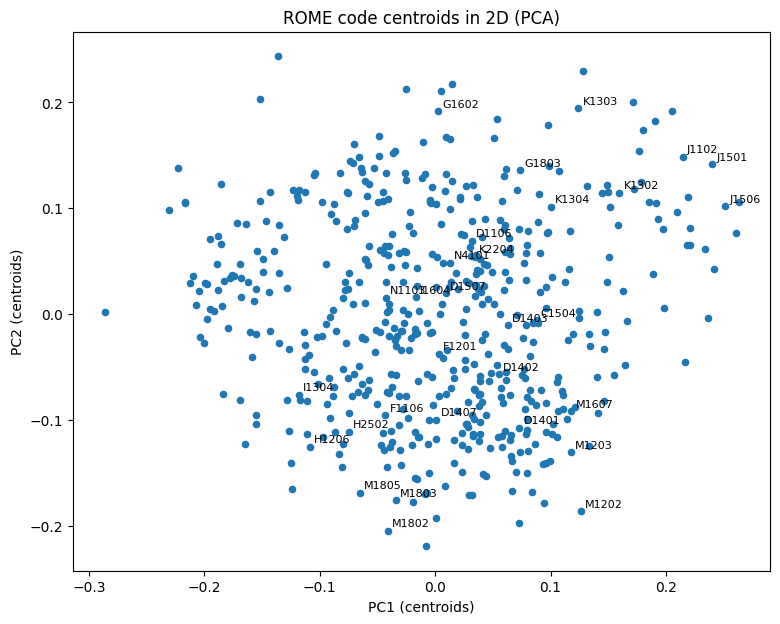

In [290]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

C = np.vstack(rome_centroids["centroid"].to_numpy())  # (n_rome, k90)

pca2 = PCA(n_components=2, random_state=0)
C2 = pca2.fit_transform(C)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(C2[:, 0], C2[:, 1], s=20)  # don't set colors

ax.set_xlabel("PC1 (centroids)")
ax.set_ylabel("PC2 (centroids)")
ax.set_title("ROME code centroids in 2D (PCA)")

# Optional: label top N biggest ROME codes by offers (to avoid clutter)
topN = 30
top_idx = np.argsort(-rome_centroids["n_offers"].to_numpy())[:topN]
for i in top_idx:
    ax.annotate(rome_centroids.loc[i, "job_ROME_code"], (C2[i, 0], C2[i, 1]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")

plt.show()


## Tests - similarity between ROME


In [291]:
import numpy as np

def cosine_similarity_matrix(X: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between all rows of X.
    X: (n, d)
    Returns: (n, n)
    """
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    return X_norm @ X_norm.T


### ROME


In [292]:
def top_k_similar_rome(
    rome_centroids: pd.DataFrame,
    target_rome: str,
    k: int = 10,
    emb_col: str = "centroid",
    rome_col: str = "job_ROME_code",
):
    """
    Return top-k most similar job_ROME_code to target_rome
    using cosine similarity on centroid embeddings.
    """
    # --- sanity checks ---
    if target_rome not in set(rome_centroids[rome_col]):
        raise ValueError(f"{target_rome} not found in rome_centroids")

    # --- stack embeddings ---
    X = np.vstack(rome_centroids[emb_col].to_numpy())
    romes = rome_centroids[rome_col].to_numpy()

    # --- normalize ---
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

    # --- target index ---
    i = np.where(romes == target_rome)[0][0]

    # --- cosine similarities ---
    sims = X_norm @ X_norm[i]

    # --- rank (exclude itself) ---
    order = np.argsort(-sims)
    order = order[order != i][:k]

    out = pd.DataFrame({
        rome_col: romes[order],
        "cosine_similarity": sims[order],
    })

    return out


In [293]:
top10 = top_k_similar_rome(
    rome_centroids,
    target_rome="H1206",   # example
    k=10
)

print(top10)


  job_ROME_code  cosine_similarity
0         H1203           0.874021
1         H1402           0.850143
2         H1209           0.790191
3         H1404           0.781141
4         H1208           0.776645
5         F1106           0.770444
6         I1305           0.767583
7         M1805           0.766357
8         F1101           0.747450
9         H1202           0.731330


In [294]:
df[df['job_ROME_code']=="H1206"].iloc[0]['description']

"au sein du pôle ingénierie, vous collaborez à l'ensemble des études de l'équipe de maîtrise d'œuvre. vous dessinez des plans de différents projets de l'agence. vous rédigez les pièces des dossiers de consultation des entreprises. vous dimensionnez les ouvrages. vous assistez l'équipe dans la gestion de l'économie de projet, et notamment dans le choix des prestations, l'établissement des métrés et l'analyse d'offres.\n\nsuivant votre expérience et votre motivation, vous pourrez également être amené-e à concevoir avec les différents acteurs : architectes, ingénieurs, entreprises...\n\nprofil recherché\nconstructif-ve, vous osez et savez quand poser les bonnes questions.\n\nrigoureux-se et appliqué-e, vous maitrisez la concordance de vos documents,\n\ndébrouillard-e, vous savez imaginer des solutions,\n\ninvesti-e, vous êtes prêt à remonter les manches pour l'équipe,\n\nadaptable, vous vous sentez prêt à affronter tout type de situation.\n\nniveau d'études : bac +5 ou bac +2 expérimenté\

In [295]:
rome_centroids.loc[rome_centroids["job_ROME_code"] == "H1206"]

,job_ROME_code,centroid,n_offers
211,H1206,"[-0.04952796, -0.16342686, -0.11654364, 0.0079...",9736


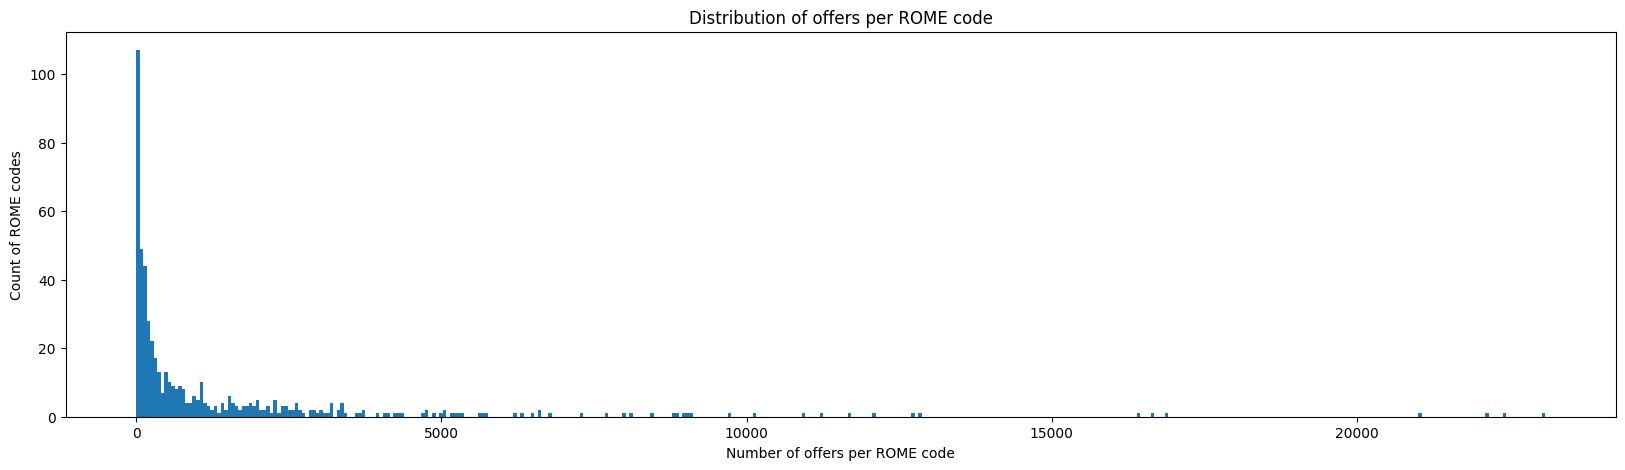

In [296]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
plt.hist(rome_centroids["n_offers"], bins=400)
plt.xlabel("Number of offers per ROME code")
plt.ylabel("Count of ROME codes")
plt.title("Distribution of offers per ROME code")
plt.show()


### SIREN

In [297]:
import numpy as np
import pandas as pd

def top_k_similar_firms(
    firm_centroids: pd.DataFrame,
    df: pd.DataFrame,
    target_siren: str,
    k: int = 10,
    emb_col: str = "centroid",
    firm_col: str = "SIREN",
    name_col: str = "entreprise_nom",
):
    """
    Return top-k most similar firms to target_siren using cosine similarity
    on centroid embeddings, with firm names.
    """

    # --- sanity check ---
    if target_siren not in set(firm_centroids[firm_col]):
        raise ValueError(f"{target_siren} not found in firm_centroids")

    # --- build SIREN -> entreprise_nom mapping (first occurrence) ---
    siren_to_name = (
        df[[firm_col, name_col]]
        .dropna()
        .drop_duplicates(subset=firm_col)
        .set_index(firm_col)[name_col]
    )

    # --- stack embeddings ---
    X = np.vstack(firm_centroids[emb_col].to_numpy())
    sirens = firm_centroids[firm_col].to_numpy()

    # --- normalize ---
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

    # --- target index ---
    i = np.where(sirens == target_siren)[0][0]

    # --- cosine similarities ---
    sims = X_norm @ X_norm[i]

    # --- rank (exclude itself) ---
    order = np.argsort(-sims)
    order = order[order != i][:k]

    out = pd.DataFrame({
        firm_col: sirens[order],
        "entreprise_nom": [siren_to_name.get(s, None) for s in sirens[order]],
        "cosine_similarity": sims[order],
    })

    return out


In [298]:
print(df.loc[df["entreprise_nom"] == "capgemini"][["entreprise_nom", "SIREN"]].head(100))

       entreprise_nom      SIREN
1998        capgemini  330703844
3008        capgemini  330703844
6734        capgemini  330703844
7230        capgemini  330703844
9309        capgemini  330703844
...               ...        ...
115013      capgemini  330703844
115491      capgemini  330703844
115547      capgemini  330703844
118469      capgemini  330703844
120596      capgemini  330703844

[100 rows x 2 columns]


In [299]:
df[df['entreprise_nom']=='thales dms france sas'].iloc[1]['description']

" qui sommes-nous ?   l’activité systèmes de missions de défense fournit des équipements, des solutions et des services liés aux systèmes de combat électroniques, de surveillance et de reconnaissance, de combat naval, de surface et de lutte sous la mer.  du développement à l’intégration en passant par la réparation et le maintien en condition opérationnelle, le site de brest couvre l’ensemble du cycle de vie de systèmes et équipements de patrouille et surveillance maritimes, de guerre électronique navale, aéroportée et terrestre ainsi que des systèmes sonars pour chasseurs de mines et produits acoustiques pour la lutte sous-marine aéroportée (sonars trempés et systèmes de traitement de bouées).  au sein de la direction des systèmes d'information, le  domaine dsi/  engineering  est déployé sur les 3 sites de dms (defence mission systems) brest, bordeaux et paris.  il met en œuvre, déploie, personnalise et assure le support des ateliers de développement système, matériel et logiciel. il 

In [300]:
df[df['entreprise_nom']=='capgemini'].iloc[:]['description']

1998       contexte    pour accompagner nos clients dans...
3008      votre profil avant tout passionné(e) d'informa...
6734      description du poste :capgemini  est un leader...
7230       le profil : * tu recherches une alternance po...
9309      description du poste :capgeminide 6 collaborat...
                                ...                        
803430    capgemini est un leader mondial du conseil, de...
803926         votre role, votre avenir     le directeur...
804424    capgemini est un leader mondial du conseil, de...
804669    construisez votre parcours et révélez le meill...
804952      <h2>capgemini recherche …</h2><p>capgemini e...
Name: description, Length: 617, dtype: object

In [301]:
top10 = top_k_similar_firms(
    firm_centroids=firm_centroids,
    df=df,
    target_siren="330703844",  # example
    k=20
)

print(top10)


        SIREN                 entreprise_nom  cosine_similarity
0   652025792              capgemini service           0.893960
1   328781786               capgemini france           0.892444
2   479766842  capgemini technology services           0.850675
3   444495774          capgemini engineering           0.815110
4   550502918                         sogeti           0.796535
5   887684728               capgemini invent           0.756170
6   408024719                           atos           0.702264
7   330130410                            gfi           0.689951
8   385365713                         inetum           0.683853
9   326820065                   sopra steria           0.681361
10  448109991                          capfi           0.679130
11  912058328                   hardis group           0.678692
12  402968655                       devoteam           0.676660
13  909806168               accenture-france           0.669330
14  428757124                       afd.

# Stat desc

## Distribution of cosine sim


This section provides stats desc on similarities between job offers and between centroids.



### Between firm (and between ROME)

Similarities between firm centroids (resp ROME)

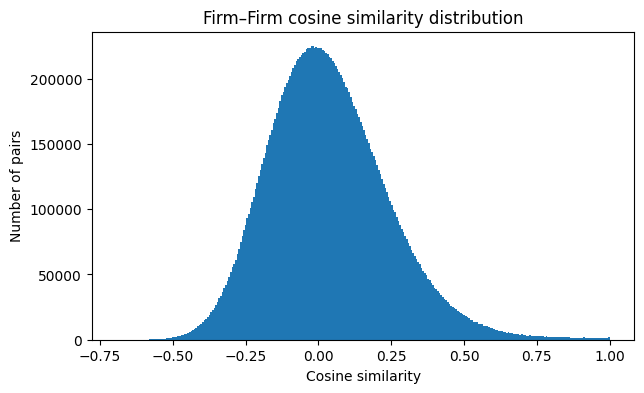

In [302]:
import numpy as np

X_firm = np.vstack(firm_centroids["centroid"].to_numpy())
X_firm = X_firm / np.linalg.norm(X_firm, axis=1, keepdims=True)

# full cosine similarity matrix
S_firm = X_firm @ X_firm.T

# keep upper triangle, exclude diagonal
i, j = np.triu_indices_from(S_firm, k=1)
sims_firm = S_firm[i, j]


import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(sims_firm, bins=300)
plt.xlabel("Cosine similarity")
plt.ylabel("Number of pairs")
plt.title("Firm–Firm cosine similarity distribution")
plt.show()


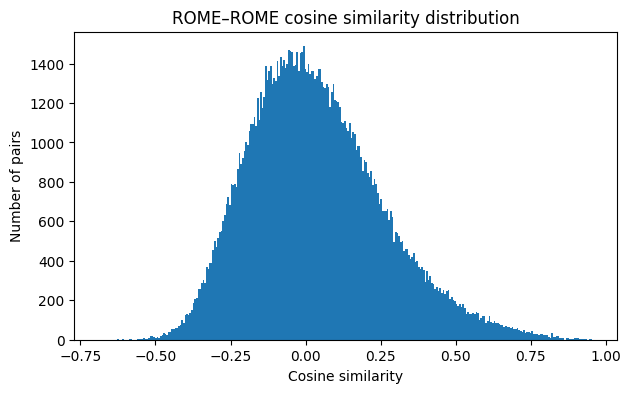

In [303]:
X_rome = np.vstack(rome_centroids["centroid"].to_numpy())
X_rome = X_rome / np.linalg.norm(X_rome, axis=1, keepdims=True)

S_rome = X_rome @ X_rome.T
i, j = np.triu_indices_from(S_rome, k=1)
sims_rome = S_rome[i, j]

plt.figure(figsize=(7, 4))
plt.hist(sims_rome, bins=300)
plt.xlabel("Cosine similarity")
plt.ylabel("Number of pairs")
plt.title("ROME–ROME cosine similarity distribution")
plt.show()


In [304]:
print(f"mean between-firm cosine similarity : {np.mean(sims_firm)}")
print(f"std between-firm cosine similarity : {np.std(sims_firm)}")

print(f"mean between-rome cosine similarity : {np.mean(sims_rome)}")
print(f"std between-rome cosine similarity : {np.std(sims_rome)}")

mean between-firm cosine similarity : 0.035597946494817734
std between-firm cosine similarity : 0.20580244064331055
mean between-rome cosine similarity : 0.037169117480516434
std between-rome cosine similarity : 0.22428566217422485


In [305]:
print(len(sims_firm))
print(len(sims_rome))

print(len(X_firm))
print(len(X_rome))

print(len(S_firm))
print(len(S_rome))

19490646
140715
6244
531
6244
531


### Within firm (and ROME) similarities

Compute average coherence of firms : are offers within a given firm similar enough ?

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def l2_normalize(vec: np.ndarray) -> np.ndarray:
    v = np.asarray(vec, dtype=np.float32)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def mean_pairwise_cosine_from_unit_vectors(X_unit: np.ndarray) -> float:
    """
    X_unit: (n, d) matrix of unit-normalized vectors.
    Returns mean cosine over all pairs i<j. If n<2 -> NaN.
    """
    n = X_unit.shape[0]
    if n < 2:
        return np.nan
    s = X_unit.sum(axis=0)                 # (d,)
    s2 = float(np.dot(s, s))               # ||sum||^2
    return (s2 - n) / (n * (n - 1))        # mean over pairs



In [307]:
def compute_group_mean_within_cosine(
    df: pd.DataFrame,
    group_cols,
    emb_col: str = "embedding_pca",
    min_obs: int = 2,
):
    """
    For each group, compute mean pairwise cosine similarity among offers (rows) in that group.
    Uses O(n*d) trick (no n^2) by unit-normalizing embeddings.
    Returns a DataFrame with group cols + mean_within_cos + n_obs.
    """
    # ensure numpy arrays + unit-normalize once
    E_unit = df[emb_col].apply(l2_normalize)

    tmp = df[group_cols].copy()
    tmp["_emb_unit"] = list(E_unit.to_numpy())

    def agg_fun(g):
        X = np.vstack(g["_emb_unit"].to_numpy())
        return pd.Series({
            "mean_within_cos": mean_pairwise_cosine_from_unit_vectors(X),
            "n_obs": len(g),
        })

    out = tmp.groupby(group_cols, sort=False).apply(agg_fun).reset_index()

    # optional filter
    out = out.loc[out["n_obs"] >= min_obs].copy()
    return out


In [308]:
# 1) Within-firm (SIREN)
within_firm = compute_group_mean_within_cosine(
    df,
    group_cols=["SIREN"],
    emb_col="embedding_pca",
    min_obs=2
)

# 2) Within-ROME
within_rome = compute_group_mean_within_cosine(
    df,
    group_cols=["job_ROME_code"],
    emb_col="embedding_pca",
    min_obs=2
)

# 3) Within (SIREN × ROME)
within_siren_rome = compute_group_mean_within_cosine(
    df,
    group_cols=["SIREN", "job_ROME_code"],
    emb_col="embedding_pca",
    min_obs=2
)


C:\Users\benjamin.lengereau\AppData\Local\Temp\ipykernel_33424\494176148.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = tmp.groupby(group_cols, sort=False).apply(agg_fun).reset_index()
C:\Users\benjamin.lengereau\AppData\Local\Temp\ipykernel_33424\494176148.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = tmp.groupby(group_cols, sort=False).apply(agg_fun).reset_index()
C:\Users\benjamin.lengerea

In [309]:
within_siren_rome = within_siren_rome.loc[within_siren_rome["n_obs"] >= 3].copy()


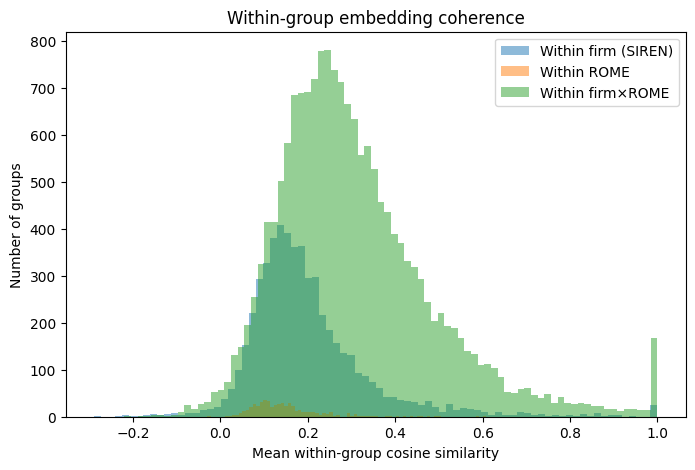

In [310]:
plt.figure(figsize=(8, 5))
plt.hist(within_firm["mean_within_cos"].dropna(), bins=80, alpha=0.5, label="Within firm (SIREN)")
plt.hist(within_rome["mean_within_cos"].dropna(), bins=80, alpha=0.5, label="Within ROME")
plt.hist(within_siren_rome["mean_within_cos"].dropna(), bins=80, alpha=0.5, label="Within firm×ROME")

plt.xlabel("Mean within-group cosine similarity")
plt.ylabel("Number of groups")
plt.legend()
plt.title("Within-group embedding coherence")
plt.show()


In [311]:
print(f"mean within-firm cosine similarity : {np.mean(within_firm["mean_within_cos"].dropna())}")
print(f"std within-firm cosine similarity : {np.std(within_firm["mean_within_cos"].dropna())}")

print(f"mean within-rome cosine similarity : {np.mean(within_rome["mean_within_cos"].dropna())}")
print(f"std within-rome cosine similarity : {np.std(within_rome["mean_within_cos"].dropna())}")

print(f"mean within-romexfirm cosine similarity : {np.mean(within_siren_rome["mean_within_cos"].dropna())}")
print(f"std within-romexfirm cosine similarity : {np.std(within_siren_rome["mean_within_cos"].dropna())}")


mean within-firm cosine similarity : 0.20032723520299464
std within-firm cosine similarity : 0.1433759547046382
mean within-rome cosine similarity : 0.14772078896982585
std within-rome cosine similarity : 0.08226978545739352
mean within-romexfirm cosine similarity : 0.30788958751031575
std within-romexfirm cosine similarity : 0.18215912783091234


In [253]:
# Diagnostic rapide
print(within_firm["mean_within_cos"].median())        # cohérence médiane firm
print(within_siren_rome["mean_within_cos"].median())  # cohérence médiane firm×ROME
print(within_siren_rome["n_obs"].describe())  

0.1652686507273943
0.24417505508814102
count    2041.000000
mean       32.339539
std       115.516839
min         3.000000
25%         3.000000
50%         5.000000
75%        11.000000
max      1854.000000
Name: n_obs, dtype: float64


In [238]:
print(len(df))

80500


In [269]:
within_firm.loc[within_firm["mean_within_cos"] > 0.95].sort_values("mean_within_cos", ascending=False)


,SIREN,mean_within_cos,n_obs
122,429213655,1.000000,2.0
710,216300657,1.000000,2.0
687,924446610,1.000000,2.0
1578,539634915,1.000000,2.0
1606,409982154,1.000000,2.0
1261,751888769,1.000000,2.0
1223,501191720,1.000000,2.0
1000,808446033,1.000000,2.0
1702,450689286,1.000000,2.0
2642,493128128,1.000000,2.0


In [273]:
df[df['SIREN']=='799146824']

,ID_JOCAS,annee,mois,entreprise_nom,location_zipcode,description,job_ROME_code,contractType,SIREN,NAF_Code,Employee_Range,Company_Category,Director_Birth_Year,Company_Creation_Date,description_clean,embedding,embedding_pca,job_title
20716,jobintree_2022-05-18_12683,2022,5,ignition program,75000.0,description du poste :candidate chez ignition ...,M1403,CDI,799146824,85.59A,None,PME,1955.0,2014-01-01,,"[-0.11883828, 0.04829867, -0.0025480704, -0.01...","[1.0937909, -0.03612136, 0.016403457, 0.019350...",DATA ANALYST POUR 1500 STARTUPS [CDI] (H/F)
72209,JOBINTREE_2019-08-10_9171,2019,8,ignition program,92220.0,en bref candidater chez ignition program te p...,M1806,Stage,799146824,85.59A,None,PME,1955.0,2014-01-01,,"[-0.11883828, 0.04829867, -0.0025480704, -0.01...","[1.0937909, -0.03612136, 0.016403457, 0.019350...",Emploi consultant junior @1200 startups - bagn...
75946,JOBINTREE_2019-08-10_9306,2019,8,ignition program,3170.0,en bref candidater chez ignition program te p...,M1805,Stage,799146824,85.59A,None,PME,1955.0,2014-01-01,,"[-0.11883828, 0.04829867, -0.0025480704, -0.01...","[1.0937909, -0.03612136, 0.016403457, 0.019350...",Emploi analyste senior @1200 startups - chambl...
